# Max value and data columns check

In [1]:
import os
import pandas as pd
from my_helpers import *

In [2]:
%load_ext autoreload
%autoreload 2

In [57]:
folder_path = '../data'  
max_values = []  
min_values = []  
separators = ' '
corrupted_files = ['../data/DATA2803/6ALEXANDRA/ALEXANDRA_5_DT_100_rawdata.csv','../data/DATA2803/6ALEXANDRA/ALEXANDRA_4_DQ_100_rawdata.csv','../data/DATA2903/7Jules']
sniffer = csv.Sniffer()
cap_text_cols = ['TimeStamps', 'MergeTimeStamps', 'ScanSizeX', 'ScanSizeY']
cap_numeric_cols =  list(map(str,range(3024)))
cap_cols = cap_text_cols + cap_numeric_cols
processed_cap_cols = cap_text_cols + ['cap_img','trial','gesture','subject','day']
wrist_cols = ['wrist_x','wrist_y','wrist_z']
finger_cols = sum([[f'{x}_{y}_x', f'{x}_{y}_y', f'{x}_{y}_z'] for x in ['Thumb','Index','Middle','Ring','Pinky'] for y in range(5)],[]) 
last_fingers_cols = [x for x in finger_cols if '_4_' in x]
day_cols = ['Timestamp','skeleton',	'ScanSizeX','ScanSizeY','trial'	,'gesture','subject','day','cap_img']

skel_cols = ['Timestamp'] + wrist_cols + finger_cols
gestures = pd.read_csv('../data/StudentList_isl.csv')
no_cap=[]
ignored=[]
trunc=True

# Loop through each day data folder
for folder in os.listdir(folder_path):

    if not folder.startswith('DATA'):  
        continue

    path = os.path.join(folder_path, folder)
    day_data = pd.DataFrame(columns=day_cols)
    day = ''.join([x for x in folder if x.isdigit()])
    # Loop through each kid data folder
    for kid in os.listdir(path):

        kid_folder = os.path.join(path, kid)

        if(kid_folder) in corrupted_files:
            continue

        skeleton_file = [f for f in os.listdir(kid_folder) if f.endswith('handleap.csv')]

        if len(skeleton_file) != 1:
            #1 occurence of this error
            raise ValueError('Found more than one skeleton file')
        
        skeleton_path = os.path.join(kid_folder, skeleton_file[0])
        kid_skeleton = read_skeleton(skeleton_path,sniffer,skel_cols)
        kid_skeleton = process_skeleton(kid_skeleton,last_fingers_cols,trunc=trunc)
        print(f'Processed {skeleton_file[0]} length : {len(kid_skeleton)}''')
        kid_cap = pd.DataFrame(columns=processed_cap_cols).rename(columns={'TimeStamps': 'Timestamp'})

        idx = int(''.join([x for x in kid if x.isdigit()]))
        native_gesture = gestures.loc[idx-1].native_grasp
    
        # Loop through each gesture data, process and concatenate
        for filename in os.listdir(kid_folder):
            if filename.endswith('rawdata.csv'):  # Check only files that end with'rawdata.csv'r
                file_path = os.path.join(kid_folder, filename)
                
                if (file_path in corrupted_files) :
                    print(f'Corrupted file {file_path}')
                    continue

                cap_img = read_cap_img(file_path,sniffer,cap_cols)
                
                #check for max and min values of capactive images pixels
                max_value = cap_img[cap_numeric_cols].values.max()
                min_value = cap_img[cap_numeric_cols].values.min()
                max_values.append(max_value)
                min_values.append(min_value)

                cap_img = process_cap_img(cap_img,trunc=trunc)
                
                f = filename.split('_')
                trial , gesture = f[1], f[2]

                #add folders informatiom to data
                cap_img['trial'] = trial
                cap_img['gesture'] = native_gesture if gesture == 'UP' else gesture
                cap_img['subject'] = idx
                cap_img['day'] = day

                print(f'Processed {filename} length : {len(cap_img)}''')
                kid_cap = pd.concat([kid_cap,cap_img],ignore_index=True)

        #add result to day data
        if kid_cap.empty:
            print(f'No cap data for {kid}')
            no_cap.append(kid)
            print('')
            continue
        
        kid_data = map_cap_img_to_skeleton(kid_skeleton,kid_cap)
        
        if(kid_data.empty):
            print(f'No matching skeleton cap data for {kid}')
            ignored.append(kid)
            print('')
            continue
        
        day_data = pd.concat([day_data,kid_data],ignore_index=True)    
        print(f'Finished {kid} mapping length  : {len(kid_data)}''')
        print('')

    day_data.to_pickle(f'../data/processed/day{day}.pkl')
    print(f'Finished day {day} length  : {len(day_data)}''')
    print('*'*50)


Processed useryaman_2023-03-30_11-35-18_1644_handleap.csv length : 1644
Processed YAMAN_3_DQ_100_rawdata.csv length : 3040
Processed YAMAN_4_LQ_100_rawdata.csv length : 2578
Processed YAMAN_1_UP_100_rawdata.csv length : 4510
Processed YAMAN_5_LT_100_rawdata.csv length : 3479
Processed YAMAN_2_DT_100_rawdata.csv length : 8125
Processed YAMAN_6_UP_100_rawdata.csv length : 2856
Finished 16Yaman mapping length  : 375

Processed userclemence_2023-03-30_11-05-54_8874_handleap.csv length : 8874
Processed CLEMENCE_4_LT_100_rawdata.csv length : 6
No matching skeleton cap data for 15Clemence

Processed useranna_sophia_2023-03-30_15-25-42_10472_handleap.csv length : 10472
Processed ANNA SOFIA_4_DQ_100_rawdata.csv length : 350
Processed ANNA SOFIA_1_UP_100_rawdata.csv length : 54
Finished 21AnnaSofia mapping length  : 36

Processed userlucas_2023-03-30_13-09-48_2073_handleap.csv length : 2073
Processed LUCAS_1_UP_100_rawdata.csv length : 4974
Processed LUCAS_4_DQ_100_rawdata.csv length : 2990
Proc

In [58]:
ignored

['15Clemence',
 '26Adya',
 '23Keeva',
 '4YAVIN',
 '3MARIA',
 '6ALEXANDRA',
 '30Thibaud',
 '31Aron',
 '9Leela']

In [59]:
no_cap

['8Miranda']

In [60]:
separators

' '

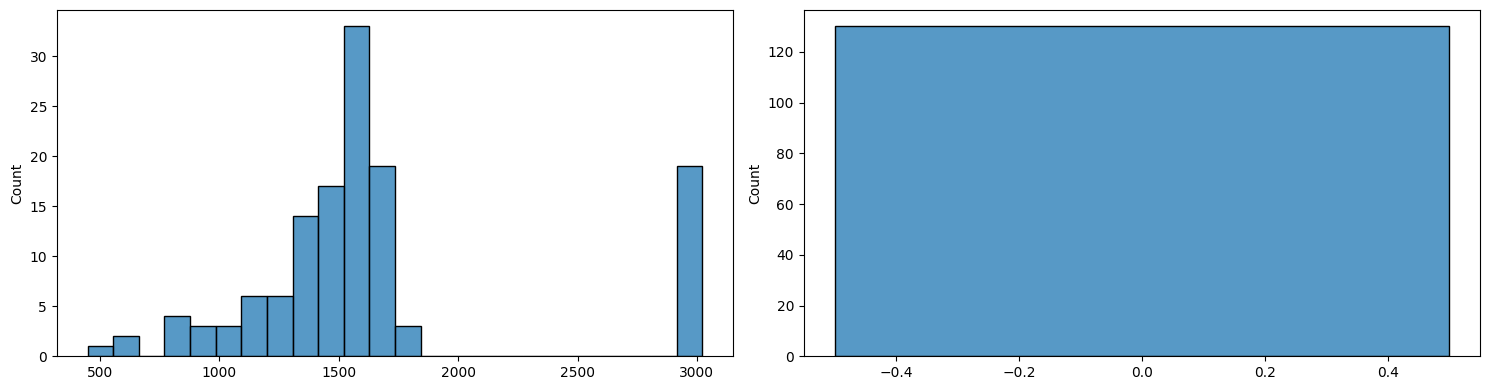

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

ax, fig = plt.subplots(1,2,figsize=(15,4))
sns.histplot(max_values, ax=fig[0])
sns.histplot(min_values, ax=fig[1])
plt.tight_layout()